
Build an end-to-end machine learning system to:
Forecast short-term temperature trends using historical weather data

In [ ]:

import os
os.chdir('..')

#Visualization
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data from MongoDB
from db.mongo_loader import load_weather_data

#Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import joblib

Loading data 

In [ ]:
df=load_weather_data()
print(df.head())

                    time  temperature_2m  relative_humidity_2m  pressure_msl  \
8496 2020-01-01 00:00:00            22.0                    91        1013.8   
8497 2020-01-01 01:00:00            21.4                    93        1013.2   
8498 2020-01-01 02:00:00            21.2                    93        1012.7   
8499 2020-01-01 03:00:00            21.0                    94        1012.1   
8500 2020-01-01 04:00:00            21.0                    93        1012.0   

      windspeed_10m  cloudcover  rain  
8496            9.0          27   0.0  
8497            7.6          51   0.0  
8498            7.7          55   0.0  
8499            8.0          88   0.0  
8500            8.3          95   0.0  


In [ ]:
# Convert 'time' column to datetime and set as index for time series analysis
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')
df = df.sort_index()

Data preprocessing

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53184 entries, 2020-01-01 00:00:00 to 2026-01-24 23:00:00
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   temperature_2m        53184 non-null  float64
 1   relative_humidity_2m  53184 non-null  int64  
 2   pressure_msl          53184 non-null  float64
 3   windspeed_10m         53184 non-null  float64
 4   cloudcover            53184 non-null  int64  
 5   rain                  53184 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 2.8 MB


In [ ]:
# Identify columns with missing values
df.apply(pd.isnull).sum()

temperature_2m          0
relative_humidity_2m    0
pressure_msl            0
windspeed_10m           0
cloudcover              0
rain                    0
dtype: int64

In [ ]:
# Count how many rows are duplicates
df.duplicated().sum()

np.int64(8)

In [ ]:
# Check the data type of each column
df.dtypes

temperature_2m          float64
relative_humidity_2m      int64
pressure_msl            float64
windspeed_10m           float64
cloudcover                int64
rain                    float64
dtype: object

In [ ]:

df.describe()

,temperature_2m,relative_humidity_2m,pressure_msl,windspeed_10m,cloudcover,rain
count,53184.000000,53184.000000,53184.000000,53184.000000,53184.000000,53184.000000
mean,23.968081,81.859131,1011.032875,9.377196,76.672101,0.210644
std,2.832831,13.700789,2.036496,5.620240,31.697891,0.854388
min,15.100000,16.000000,1003.500000,0.000000,0.000000,0.000000
25%,22.000000,74.000000,1009.600000,4.700000,57.000000,0.000000
50%,23.300000,86.000000,1011.000000,8.500000,96.000000,0.000000
75%,25.900000,92.000000,1012.400000,13.500000,100.000000,0.100000
max,35.900000,100.000000,1018.800000,29.100000,100.000000,23.500000


In [ ]:

df_daily = df.resample("D").agg({
    "temperature_2m": "mean",
    "relative_humidity_2m": "mean",
    "pressure_msl": "mean",
    "windspeed_10m": "mean",
    "cloudcover": "mean",
    "rain": "sum"
})


In [12]:
df_daily.head()

,temperature_2m,relative_humidity_2m,pressure_msl,windspeed_10m,cloudcover,rain
time,,,,,,
2020-01-01,24.254167,81.000000,1013.529167,10.620833,57.000000,0.0
2020-01-02,24.295833,82.375000,1014.508333,14.641667,31.458333,0.5
2020-01-03,24.708333,79.375000,1013.366667,15.616667,24.916667,0.0
2020-01-04,24.387500,80.333333,1012.241667,10.070833,15.250000,0.7
2020-01-05,24.208333,77.875000,1011.866667,14.733333,20.583333,0.0


In [13]:
df_daily["day_of_year"] = df_daily.index.dayofyear
df_daily["month"] = df_daily.index.month
df_daily["week_of_year"] = df_daily.index.isocalendar().week.astype(int)


In [14]:
df_daily.head()

,temperature_2m,relative_humidity_2m,pressure_msl,windspeed_10m,cloudcover,rain,day_of_year,month,week_of_year
time,,,,,,,,,
2020-01-01,24.254167,81.000000,1013.529167,10.620833,57.000000,0.0,1,1,1
2020-01-02,24.295833,82.375000,1014.508333,14.641667,31.458333,0.5,2,1,1
2020-01-03,24.708333,79.375000,1013.366667,15.616667,24.916667,0.0,3,1,1
2020-01-04,24.387500,80.333333,1012.241667,10.070833,15.250000,0.7,4,1,1
2020-01-05,24.208333,77.875000,1011.866667,14.733333,20.583333,0.0,5,1,1


In [15]:
for lag in [1, 2, 3, 7, 14]:
    df_daily[f"temp_lag_{lag}"] = df_daily["temperature_2m"].shift(lag)


In [16]:
df_daily["temp_roll_7"]  = df_daily["temperature_2m"].shift(1).rolling(7).mean()
df_daily["temp_roll_14"] = df_daily["temperature_2m"].shift(1).rolling(14).mean()


In [17]:
targets = []
for i in range(1, 8):
    col = f"target_day_{i}"
    df_daily[col] = df_daily["temperature_2m"].shift(-i)
    targets.append(col)

In [18]:
df_model = df_daily.dropna()

In [19]:
train = df_model[df_model.index < "2024-01-01"]
test  = df_model[df_model.index >= "2024-01-01"]


In [20]:
X_train = train.drop(columns=targets)
y_train = train[targets]

X_test  = test.drop(columns=targets)
y_test  = test[targets]


In [21]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

# Ensure no NaNs
print(X_train.isna().sum().sum())
print(y_train.isna().sum().sum())


(1447, 16) (1447, 7)
(748, 16) (748, 7)
0
0


In [ ]:

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:


preds = model.predict(X_test)

for i in range(7):
    mae = mean_absolute_error(y_test.iloc[:, i], preds[:, i])
    print(f"Day +{i+1} MAE: {mae:.2f}")


Day +1 MAE: 0.48
Day +2 MAE: 0.56
Day +3 MAE: 0.59
Day +4 MAE: 0.61
Day +5 MAE: 0.62
Day +6 MAE: 0.63
Day +7 MAE: 0.65


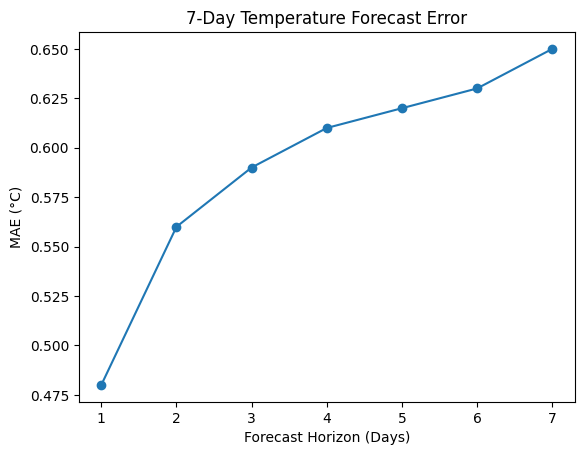

In [ ]:

mae = [0.48, 0.56, 0.59, 0.61, 0.62, 0.63, 0.65]

plt.plot(range(1, 8), mae, marker='o')
plt.xlabel("Forecast Horizon (Days)")
plt.ylabel("MAE (°C)")
plt.title("7-Day Temperature Forecast Error")
plt.show()


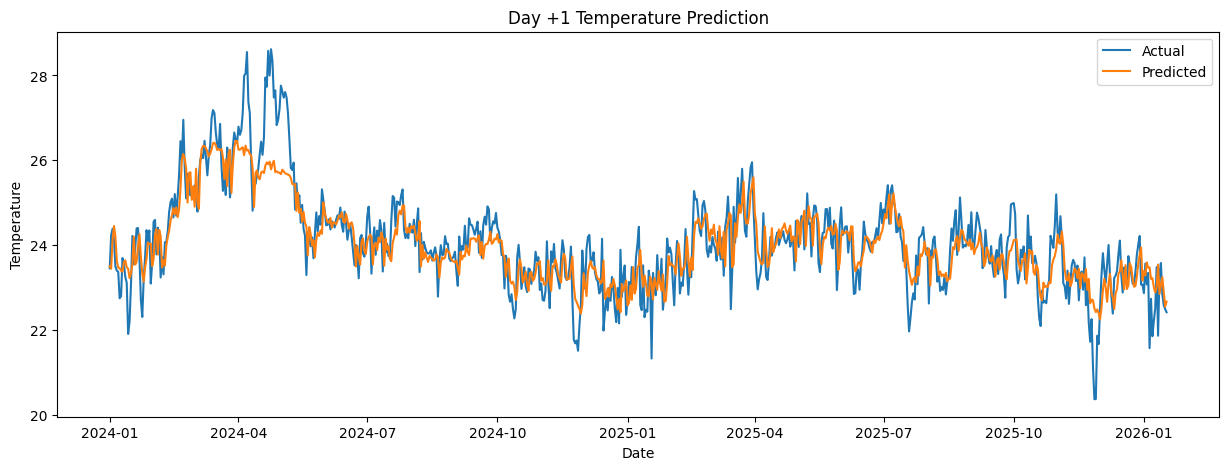

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test.iloc[:, 0], label="Actual")
plt.plot(y_test.index, preds[:, 0], label="Predicted")
plt.title("Day +1 Temperature Prediction")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()


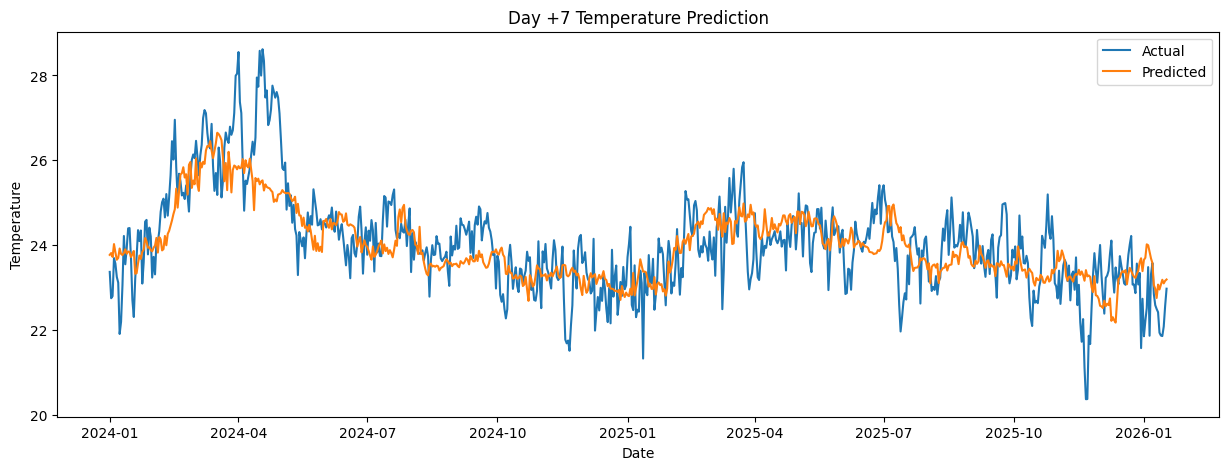

In [27]:
plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test.iloc[:, 6], label="Actual")
plt.plot(y_test.index, preds[:, 6], label="Predicted")
plt.title("Day +7 Temperature Prediction")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()


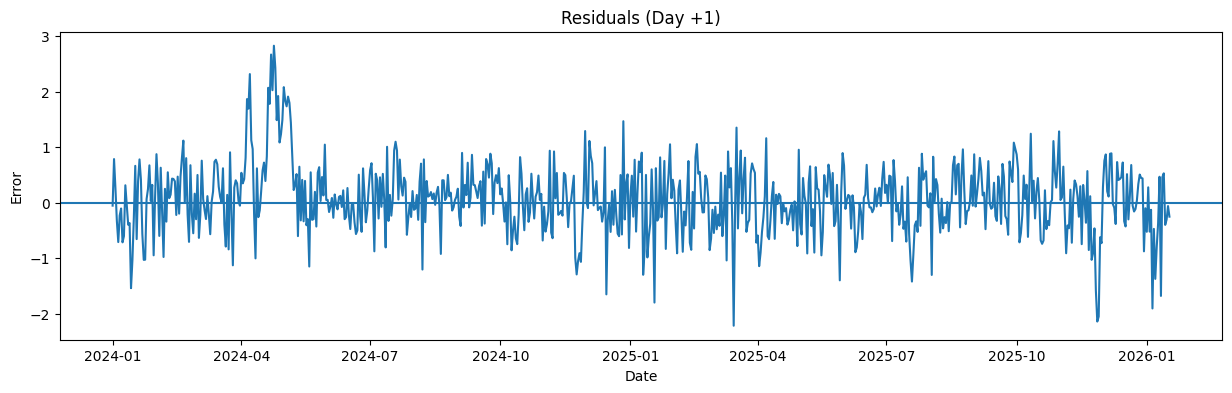

In [28]:
residuals = y_test.iloc[:, 0] - preds[:, 0]

plt.figure(figsize=(15,4))
plt.plot(y_test.index, residuals)
plt.axhline(0)
plt.title("Residuals (Day +1)")
plt.xlabel("Date")
plt.ylabel("Error")
plt.show()


In [36]:
import joblib


joblib.dump(model, "7day_temp_model.pkl")

model = joblib.load("7day_temp_model.pkl")


In [26]:
latest_row = df_model.drop(columns=targets).iloc[-1:]


In [27]:

prediction = model.predict(latest_row)
print("7-Day Temperature Forecast:")
for i, temp in enumerate(prediction[0], 1):
    print(f"Day +{i}: {temp:.2f} °C")

7-Day Temperature Forecast:
Day +1: 22.67 °C
Day +2: 22.88 °C
Day +3: 23.07 °C
Day +4: 23.19 °C
Day +5: 23.22 °C
Day +6: 23.15 °C
Day +7: 23.19 °C


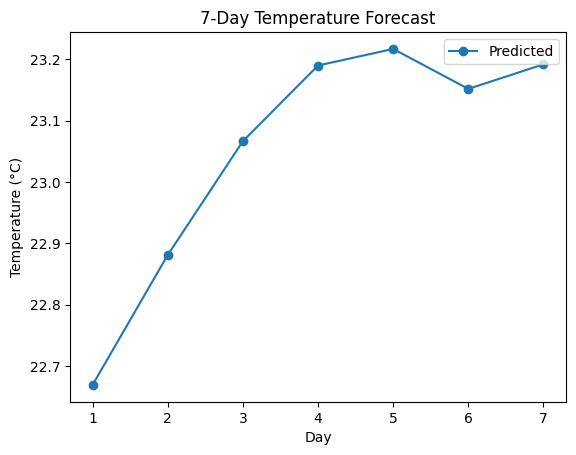

In [ ]:


plt.plot(range(1, 8), prediction[0], marker='o', label='Predicted')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.title('7-Day Temperature Forecast')
plt.legend()
plt.show()


In [30]:
predicted_temps = prediction.flatten()


In [31]:
last_date = df_model.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)


In [35]:
forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_temperature": predicted_temps
})

forecast_df


,date,predicted_temperature
0,2026-01-18,22.669365
1,2026-01-19,22.881005
2,2026-01-20,23.066379
3,2026-01-21,23.189652
4,2026-01-22,23.216702
5,2026-01-23,23.151599
6,2026-01-24,23.191618
